In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import sparse as sp

def TBU_SNM(p, phi1, phi2, omega=0, tau=0):
    """
    TBU bidireccional usando las ecuaciones de Capmany mapeadas a SNM.
    Incluye sensibilidad a la frecuencia (omega) y retardo (tau).
    """
    # Coeficientes de los acopladores
    c_a, s_a = np.sqrt(1 - p['K_a']), np.sqrt(p['K_a'])
    c_b, s_b = np.sqrt(1 - p['K_b']), np.sqrt(p['K_b'])
    
    # El multiplicador incluye la pérdida y la fase de propagación global
    multiplicador = np.sqrt(1-p['gamma_a'])*np.sqrt(1-p['gamma_b'])*np.exp(-1j*omega*tau)
    
    # Fases efectivas (programada + frecuencia)
    theta1 = phi1 + omega * tau
    theta2 = phi2 + omega * tau

    # Coeficientes de la matriz de transferencia H 
    m11 = c_a*c_b*np.sqrt(1-p['gamma_c'])*np.exp(-1j*theta1) - s_a*s_b*np.sqrt(1-p['gamma_d'])*np.exp(-1j*theta2)
    m12 = -1j*s_a*c_b*np.sqrt(1-p['gamma_c'])*np.exp(-1j*theta1) - 1j*s_b*c_a*np.sqrt(1-p['gamma_d'])*np.exp(-1j*theta2)
    m21 = -1j*s_b*c_a*np.sqrt(1-p['gamma_c'])*np.exp(-1j*theta1) - 1j*s_a*c_b*np.sqrt(1-p['gamma_d'])*np.exp(-1j*theta2)
    m22 = c_a*c_b*np.sqrt(1-p['gamma_d'])*np.exp(-1j*theta2) - s_a*s_b*np.sqrt(1-p['gamma_c'])*np.exp(-1j*theta1)

    # Matriz S local de 4x4 (mapea 4 nodos de entrada a 4 de salida) 
    # Puertos: a=0, c=1 (Entradas) | b=2, d=3 
    S_local = np.zeros((4, 4), dtype=complex)
    
    # Forward: In(a,c) -> Out(b,d)
    S_local[2, 0] = m11; S_local[2, 1] = m12
    S_local[3, 0] = m21; S_local[3, 1] = m22
    
    # Backward: In(b,d) -> Out(a,c) (Por reciprocidad Sij = Sji)
    S_local[0, 2] = m11; S_local[1, 2] = m12
    S_local[0, 3] = m21; S_local[1, 3] = m22
    
    return multiplicador * S_local

In [2]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import factorized
import matplotlib.pyplot as plt

class malla_hexagonal:
    def __init__(self, tbus_por_columna, ideal=False, seed = None):
        # 1. Configuración de geometría
        self.tbus_reales = tbus_por_columna
        self.Cols = len(tbus_por_columna)
        self.Filas = max(tbus_por_columna) 
        
        self.ideal = ideal
        self.num_puertos = self.Cols * self.Filas * 4
        self.S = sp.lil_matrix((self.num_puertos, self.num_puertos), dtype=complex)
        
        self.seed = seed
        self.params_tbus = {} 
        self.cable_loss = 1.0 if ideal else 0.99
        self._inicializar_defectos() 

    def _existe_tbu(self, c, f):
        """Verifica si la TBU (c, f) es parte del diseño real."""
        if c < 0 or c >= self.Cols: return False
        if f < 0 or f >= self.tbus_reales[c]: return False
        return True

    def _get_ids(self, c, f):
        """Calcula los 4 IDs globales de una TBU."""
        base = (c * self.Filas + f) * 4 
        return base, base+1, base+2, base+3

    def _inicializar_defectos(self):
        
        if self.seed is not None:
            np.random.seed(self.seed)
            
            
        K_mean, K_std = 0.5, 0.0433
        g_c_m, g_c_s = 0.0115, 0.01
        g_a_m, g_a_s = 0.0516, 0.0284
        for c in range(self.Cols):
            for f in range(self.tbus_reales[c]):
                if self.ideal:
                    self.params_tbus[(c,f)] = {
                        'K_a': 0.5, 'K_b': 0.5, 'gamma_a': 0.0, 'gamma_b': 0.0,
                        'gamma_c': 0.0, 'gamma_d': 0.0
                    }
                else:
                    self.params_tbus[(c,f)] = {
                        'K_a': np.clip(np.random.normal(K_mean, K_std), 0.0, 1.0),
                        'K_b': np.clip(np.random.normal(K_mean, K_std), 0.0, 1.0),
                        'gamma_a': np.clip(np.random.normal(g_c_m, g_c_s), 0.0, 1.0),
                        'gamma_b': np.clip(np.random.normal(g_c_m, g_c_s), 0.0, 1.0),
                        'gamma_c': np.clip(np.random.normal(g_a_m, g_a_s), 0.0, 1.0),
                        'gamma_d': np.clip(np.random.normal(g_a_m, g_a_s), 0.0, 1.0)
                    }
                    
    def colocar_tbus(self, fases_input):
        # Reiniciamos la matriz y conectamos cables antes de poner las TBUs
        self.S = sp.lil_matrix((self.num_puertos, self.num_puertos), dtype=complex)
        self._conectar_cables()
        for c in range(self.Cols):
            for f in range(self.tbus_reales[c]):
                p = self.params_tbus[(c,f)]
                phi1, phi2 = fases_input.get((c,f), (0,0))
                
                # Invocamos tu función de matriz de transferencia (asegúrate de que esté definida)
                H = TBU_no_ideal_bidireccional(p['K_a'], p['K_b'], p['gamma_a'], p['gamma_b'], 
                                               p['gamma_c'], p['gamma_d'], phi1, phi2, 0, 0)
                ids = self._get_ids(c,f)
                for i in range(4):
                    for j in range(4):
                        if H[i, j] != 0:
                            self.S[ids[i], ids[j]] = H[i, j]

    def _conectar_cables(self):
        cable = self.cable_loss
        # 1. Bucle por todas las columnas (incluimos la última para procesar sus verticales)
        for c in range(self.Cols):
            tipo = c % 4
            num_f = self.tbus_reales[c]
            
            for f in range(num_f):
                # Obtenemos los 4 IDs de la TBU actual (c, f)
                it, ib, ot, ob = self._get_ids(c, f)
                
                # --- A. CONEXIONES VERTICALES (Solo en columnas Tipo 0 y Tipo 2) ---
                if (tipo == 0 or tipo == 2) and f < num_f - 1:
                    d_it, d_ib, d_ot, d_ob = self._get_ids(c, f + 1)
                    if tipo == 0:
                        if f % 2 == 0:
                            self.S[ob, d_ot] = cable; self.S[d_ot, ob] = cable
                        else:
                            self.S[ib, d_it] = cable; self.S[d_it, ib] = cable
                    elif tipo == 2:
                        # Lógica inversa para Tipo 2 según tu diseño
                        if f % 2 == 0:
                            self.S[ib, d_it] = cable; self.S[d_it, ib] = cable
                        else:
                            self.S[ob, d_ot] = cable; self.S[d_ot, ob] = cable

                # --- B. CONEXIONES HORIZONTALES (Hacia la columna c+1) ---
                if c < self.Cols - 1:
                    if tipo == 0: # Contracción 6 -> 3
                        f_dest = f // 2
                        target = self._get_ids(c + 1, f_dest)
                        if f % 2 == 1:
                            self.S[ob, target[1]] = cable; self.S[target[1], ob] = cable
                        else:
                            self.S[ot, target[0]] = cable; self.S[target[0], ot] = cable

                    elif tipo == 1: # Expansión 3 -> 6
                        # Cada TBU en c conecta a dos en c+1
                        t_sup = self._get_ids(c + 1, 2 * f)
                        self.S[ot, t_sup[0]] = cable; self.S[t_sup[0], ot] = cable
                        t_inf = self._get_ids(c + 1, 2 * f + 1)
                        self.S[ob, t_inf[1]] = cable; self.S[t_inf[1], ob] = cable

                    elif tipo == 2: # Contracción 6 -> 4
                        if f == 0:
                            target = self._get_ids(c + 1, 0)
                            self.S[ob, target[1]] = cable; self.S[target[1], ob] = cable
                        elif f == num_f - 1: # f=5
                            target = self._get_ids(c + 1, self.tbus_reales[c+1] - 1)
                            self.S[ot, target[0]] = cable; self.S[target[0], ot] = cable
                        else:
                            f_dest = ((f - 1) // 2) + 1
                            target = self._get_ids(c + 1, f_dest)
                            if f % 2 == 0:
                                self.S[ob, target[1]] = cable; self.S[target[1], ob] = cable
                            else:
                                self.S[ot, target[0]] = cable; self.S[target[0], ot] = cable

                    elif tipo == 3: # Expansión 4 -> 6 (LÓGICA DOBLE RESTAURADA)
                        if f == 0:
                            target = self._get_ids(c + 1, 0)
                            self.S[ob, target[1]] = cable; self.S[target[1], ob] = cable
                        elif f == num_f - 1: # f=3
                            target = self._get_ids(c + 1, self.tbus_reales[c+1] - 1)
                            self.S[ot, target[0]] = cable; self.S[target[0], ot] = cable
                        else:
                            # TBUs centrales f=1, 2 conectan a DOS TBUs cada una
                            t_v_sup = self._get_ids(c + 1, 2 * f - 1)
                            self.S[ot, t_v_sup[0]] = cable; self.S[t_v_sup[0], ot] = cable
                            t_v_inf = self._get_ids(c + 1, 2 * f)
                            self.S[ob, t_v_inf[1]] = cable; self.S[t_v_inf[1], ob] = cable

    def detectar_puertos_externos(self):
        # Eliminamos la línea que reseteaba self.S
        # Solo calculamos cables si la matriz está vacía
        if self.S.nnz == 0:
            self._conectar_cables()
            
        S_csr = self.S.tocsr()
        puertos_externos = []
        for c in range(self.Cols):
            for f in range(self.tbus_reales[c]):
                ids_tbu = self._get_ids(c, f)
                for p_id in ids_tbu:
                    # Un puerto es externo si NO tiene cables conectados
                    # Buscamos en la matriz de cables (que debería ser simétrica)
                    if S_csr[p_id, :].nnz == 0:
                        puertos_externos.append(p_id)
        return puertos_externos

    def obtener_ids_perimetrales_ordenados(self):
        ids_libres = self.detectar_puertos_externos()
        info_puertos = []
        for p_id in ids_libres:
            total_tbu_id = p_id // 4
            c = total_tbu_id // self.Filas
            f = total_tbu_id % self.Filas
            p_local = p_id % 4
            x = c
            y = f * 2 + (1 if c % 2 != 0 else 0)
            
            if c == 0: borde = 'WEST'
            elif c == self.Cols - 1: borde = 'EAST'
            elif p_local == 0 or p_local == 2: borde = 'NORTH'
            else: borde = 'SOUTH'
            info_puertos.append({'id': p_id, 'c': c, 'f': f, 'p_local': p_local, 'x': x, 'y': y, 'borde': borde})
        
        inicio = sorted([p for p in info_puertos if p['c'] == 0 and p['f'] == 0], key=lambda x: x['p_local'], reverse=True)
        norte = sorted([p for p in info_puertos if p['borde'] == 'NORTH' and 0 < p['c'] < self.Cols-1], key=lambda x: x['x'])
        este = sorted([p for p in info_puertos if p['borde'] == 'EAST'], key=lambda x: x['y'])
        sur = sorted([p for p in info_puertos if p['borde'] == 'SOUTH' and 0 < p['c'] < self.Cols-1], key=lambda x: x['x'], reverse=True)
        oeste_resto = sorted([p for p in info_puertos if p['c'] == 0 and p['f'] > 0], key=lambda x: x['y'], reverse=True)
        return [p['id'] for p in inicio + norte + este + sur + oeste_resto]

    def obtener_matriz_S_40x40(self, ids_puertos_40):
        # Aseguramos que la matriz esté en formato CSR para cálculos rápidos
        S_sparse = self.S.tocsr()
        
        # Resolvemos (I - S)x = b
        # Si ideal=True, usamos un factor de regularización para evitar matrices singulares
        reg = 1e-12 if self.ideal else 0
        I = sp.eye(self.num_puertos, format='csr') * (1 + reg)
        
        # Factorización LU para resolver rápido múltiples entradas
        solve = factorized((I - S_sparse).tocsc())
        
        num_ext = len(ids_puertos_40)
        S_puf = np.zeros((num_ext, num_ext), dtype=complex)
        
        for i in range(num_ext):
            b = np.zeros(self.num_puertos, dtype=complex)
            b[ids_puertos_40[i]] = 1.0 # Inyectamos 1 en el puerto i
            x = solve(b)
            # El resultado en los puertos externos es la respuesta de la red
            S_puf[:, i] = x[ids_puertos_40]
            
        return S_puf

In [3]:
class malla_SNM(malla_hexagonal):

    def __init__(self, tbus_por_columna, ideal=False, seed=None):

        super().__init__(tbus_por_columna, ideal, seed)

        # Cada puerto físico tiene un nodo de entrada (i) y uno de salida (o) [cite: 101]

        self.num_nodos = self.num_puertos * 2 

        self.G = sp.lil_matrix((self.num_nodos, self.num_nodos), dtype=complex)



    def _get_nodos(self, p_id):

        """Retorna los índices (nodo_entrada, nodo_salida) para un puerto global[cite: 101]."""

        return p_id * 2, p_id * 2 + 1



    def construir_grafo(self, fases_input):

        """Mapea la estructura al grafo de flujo inicial[cite: 210]."""

        self.G = sp.lil_matrix((self.num_nodos, self.num_nodos), dtype=complex)

        

        # 1. Conexiones internas (Nodos i -> Nodos o dentro de cada TBU) [cite: 102, 105]

        for (c, f), p in self.params_tbus.items():

            phi1, phi2 = fases_input.get((c, f), (0, 0))

            S_tbu = TBU_SNM(p, phi1, phi2)

            ids_puertos = self._get_ids(c, f)

            

            for i_local in range(4):

                for j_local in range(4):

                    if S_tbu[j_local, i_local] != 0:

                        # Nodo de entrada del puerto origen -> Nodo de salida del puerto destino

                        n_in = self._get_nodos(ids_puertos[i_local])[0]

                        n_out = self._get_nodos(ids_puertos[j_local])[1]

                        self.G[n_out, n_in] = S_tbu[j_local, i_local]



        # 2. Conexiones de cables (Nodos o -> Nodos i entre TBUs) [cite: 184]

        # Usamos la lógica de conectividad física previa

        malla_temp = malla_hexagonal(self.tbus_reales, self.ideal)

        malla_temp._conectar_cables()

        conn = malla_temp.S.tocoo()

        

        for p1, p2 in zip(conn.row, conn.col):

            if p1 < p2:

                # Cable une el nodo de salida de un puerto con el de entrada del otro [cite: 184]

                n1_in, n1_out = self._get_nodos(p1)

                n2_in, n2_out = self._get_nodos(p2)

                self.G[n2_in, n1_out] = self.cable_loss

                self.G[n1_in, n2_out] = self.cable_loss



    def resolver_matriz_total(self, ids_externos):

        """

        Calcula la matriz de scattering total entre los puertos externos[cite: 188, 24].

        Equivale a simplificar todos los nodos internos[cite: 187, 873].

        """

        # I - G representa la matriz de conexiones de toda la red [cite: 211]

        I = sp.eye(self.num_nodos, format='csr')

        A = (I - self.G.tocsr()).tocsc()

        solve = factorized(A)

        

        num_ext = len(ids_externos)

        S_total = np.zeros((num_ext, num_ext), dtype=complex)

        

        for j in range(num_ext):

            # Inyectamos señal en el nodo de entrada (i) del puerto externo j [cite: 24, 39]

            b = np.zeros(self.num_nodos, dtype=complex)

            n_in_j = self._get_nodos(ids_externos[j])[0]

            b[n_in_j] = 1.0

            

            x = solve(b)

            

            # La respuesta está en los nodos de salida (o) de los puertos externos [cite: 101, 102]

            for i in range(num_ext):

                n_out_i = self._get_nodos(ids_externos[i])[1]

                S_total[i, j] = x[n_out_i]

                

        return S_total 

In [4]:
class malla_SNM_completa(malla_SNM):
    def __init__(self, tbus_por_columna, ideal=False, seed=None):
        super().__init__(tbus_por_columna, ideal, seed)
        self.mapa_tbus = self._generar_mapa_tbus()

    def _generar_mapa_tbus(self):
        """Crea el diccionario: Índice Lineal -> (Columna, Fila)"""
        mapa = {}
        contador = 0
        for c in range(self.Cols):
            for f in range(self.tbus_reales[c]):
                mapa[contador] = (c, f)
                contador += 1
        return mapa

    def programar_malla(self, config_usuario, omega=0, tau=0, fase_comun=0):
        # 1. Inicializamos TODAS las TBUs de la malla con fases aleatorias por defecto
        fases_finales = {
            coords: (np.random.uniform(0, 2*np.pi), np.random.uniform(0, 2*np.pi)) 
            for coords in self.mapa_tbus.values()
        }

        # 2. Ahora sobreescribimos SOLO las que el usuario pida
        for idx_lineal, estado in config_usuario:
            if idx_lineal in self.mapa_tbus:
                coords = self.mapa_tbus[idx_lineal]
                if estado == "x":
                    phi1, phi2 = (0, 0)
                elif estado == "=":
                    phi1, phi2 = (np.pi, 0)
                elif isinstance(estado, (int, float)):
                    theta = 2 * np.arcsin(np.sqrt(estado))
                    phi1, phi2 = (theta, 0)
                else:
                    continue # Ya es aleatoria por el paso 1

                fases_finales[coords] = (phi1 + fase_comun, phi2 + fase_comun)

        self.construir_grafo_espectral(fases_finales, omega, tau)

    
    def construir_grafo_espectral(self, fases_input, omega, tau):
        """
        Construye el grafo de flujo de señal considerando la fase de propagación[cite: 90, 862].
        """
        self.G = sp.lil_matrix((self.num_nodos, self.num_nodos), dtype=complex)
        
        # 1. Conexiones internas de las TBUs con dependencia espectral [cite: 102, 105]
        for (c, f), p in self.params_tbus.items():
            phi1, phi2 = fases_input.get((c, f), (0, 0))
            # Usamos tu función TBU_SNM que ya incluye omega y tau 
            S_tbu = TBU_SNM(p, phi1, phi2, omega, tau)
            ids_puertos = self._get_ids(c, f)
            
            for i_local in range(4):
                for j_local in range(4):
                    if S_tbu[j_local, i_local] != 0:
                        n_in = self._get_nodos(ids_puertos[i_local])[0]
                        n_out = self._get_nodos(ids_puertos[j_local])[1]
                        self.G[n_out, n_in] = S_tbu[j_local, i_local]
    
        # 2. Conexiones de cables con fase de retardo (tau) [cite: 184]
        # El cable también añade un desfase complejo según la frecuencia 
        fase_cable = np.exp(-1j * omega * tau) 
        
        # Usamos una malla temporal para identificar conexiones físicas [cite: 210]
        malla_temp = malla_hexagonal(self.tbus_reales, self.ideal)
        malla_temp._conectar_cables()
        conn = malla_temp.S.tocoo()
        
        for p1, p2 in zip(conn.row, conn.col):
            if p1 < p2:
                n1_in, n1_out = self._get_nodos(p1)
                n2_in, n2_out = self._get_nodos(p2)
                # Conexión bidireccional entre nodos Out e In de puertos adyacentes [cite: 184]
                self.G[n2_in, n1_out] = self.cable_loss * fase_cable
                self.G[n1_in, n2_out] = self.cable_loss * fase_cable

In [20]:
def graficar_salida_dbm(potencias_lineales, ids_p):
    """
    Gráfico de potencias en dBm con todos los porcentajes en vertical para evitar solapes.
    """
    suelo = -60 
    # El paper utiliza escalas logarítmicas para analizar la transmisión [cite: 862]
    potencias_dbm = 10 * np.log10(potencias_lineales + 1e-12) 
    alturas = np.maximum(potencias_dbm, suelo) - suelo
    
    plt.figure(figsize=(15, 7))
    
    # Colores: Salmón para puertos con señal (>1%), azul para el resto [cite: 850]
    colores = ['#ff7f50' if p > 0.01 else '#87ceeb' for p in potencias_lineales]
    
    plt.bar(range(len(ids_p)), alturas, bottom=suelo, 
            color=colores, edgecolor='black', alpha=0.8)
    
    for i, p in enumerate(potencias_lineales):
        es_relevante = p > 0.01
 
        # Posición base del texto (mínimo un poco por encima del suelo)
        y_pos = max(potencias_dbm[i], suelo + 1)
        
        # Configuración para que todos sean verticales
        plt.text(i, y_pos + 1, f"{p*100:.1f}%", 
                 ha='center', va='bottom', 
                 fontsize=7.5, 
                 fontweight='bold' if es_relevante else 'normal',
                 rotation=90, # <--- Todos en vertical
                 alpha=1.0 if es_relevante else 0.7)

    # Damos margen arriba para que quepan los números verticales
    plt.ylim([suelo, 15]) 
    plt.ylabel("Potencia (dBm)")
    plt.xlabel("Índice de Puerto de Salida (S)")
    plt.title("Distribución de Potencia por Puerto - Método SNM")
    
    plt.grid(axis='y', linestyle=':', alpha=0.4)
    plt.xticks(range(len(ids_p)), range(len(ids_p)), fontsize=8)
    
    plt.tight_layout()
    plt.show()
def preparar_fases(config_usuario, fase_comun=0):
    """
    Traduce estados semánticos a fases físicas añadiendo un Overall Phase Shift.
    fase_comun: Desplazamiento global que se aplica a todas las TBUs.
    """
    fases = {}
    for (tbu_id, estado) in config_usuario:
        # 1. Calculamos la fase diferencial base (la que controla el puerto de salida)
        if estado == "x":
            phi1_base, phi2_base = (0, 0)
        elif estado == "=":
            phi1_base, phi2_base = (np.pi, 0)
        elif isinstance(estado, (int, float)):
            phi1_base, phi2_base = (2 * np.arcsin(np.sqrt(estado)), 0)
        else:
            phi1_base, phi2_base = (0, 0)

        # 2. Implementamos el "Overall Phase Shift" sumando la fase común a AMBOS brazos
        # Esto es lo que te pedía tu jefe: Psi = (theta1 + theta2) / 2
        fases[tbu_id] = (phi1_base + fase_comun, phi2_base + fase_comun)
        
    return fases

def generar_configuracion_base_aleatoria(malla, seed=None):
    """
    Genera fases aleatorias. Si seed es None, cambia en cada ejecución.
    """
    if seed is not None:
        np.random.seed(seed)
    else:
        # Esto asegura que el generador global se "mueva"
        np.random.seed(None) 
    
    config = []
    for idx_lineal in malla.mapa_tbus.keys():
        # Usamos el tag "random" para que programar_malla sepa que debe dejar la fase aleatoria
        config.append((idx_lineal, "random"))
    return config
def calcular_metricas_puf(p1, p2):
    # 1. Correlación de Pearson (1 = idénticos, 0 = sin relación)
    # En una buena PUF, la correlación debe ser baja
    corr, _ = pearsonr(p1, p2)
    
    # 2. Distancia Euclidiana (Cuanto mayor, más diferentes son los chips)
    dist_euclidea = np.linalg.norm(p1 - p2)
    
    # 3. Diferencia Porcentual Media (MAE en escala lineal)
    mae = np.mean(np.abs(p1 - p2)) * 100
    
    # 4. Superposición de Potencia (Similarity Score)
    # Calculamos cuánto de la potencia cae en los mismos puertos
    overlap = np.sum(np.minimum(p1, p2)) / np.sum(p1) * 100

    print("--- MÉTRICAS DE COMPARACIÓN INTER-CHIP ---")
    print(f"1. Correlación de Pearson: {corr:.4f}")
    print(f"2. Distancia Euclidiana:  {dist_euclidea:.4f}")
    print(f"3. Error Medio Absoluto:  {mae:.2f} %")
    print(f"4. Similitud de Perfil:   {overlap:.2f} %")
    print("-" * 42)
    
    if corr < 0.7:
        print("RESULTADO: Alta Unicidad. Los chips son fácilmente distinguibles. ✅")
    else:
        print("RESULTADO: Baja Unicidad. Los chips se parecen demasiado. ⚠️")

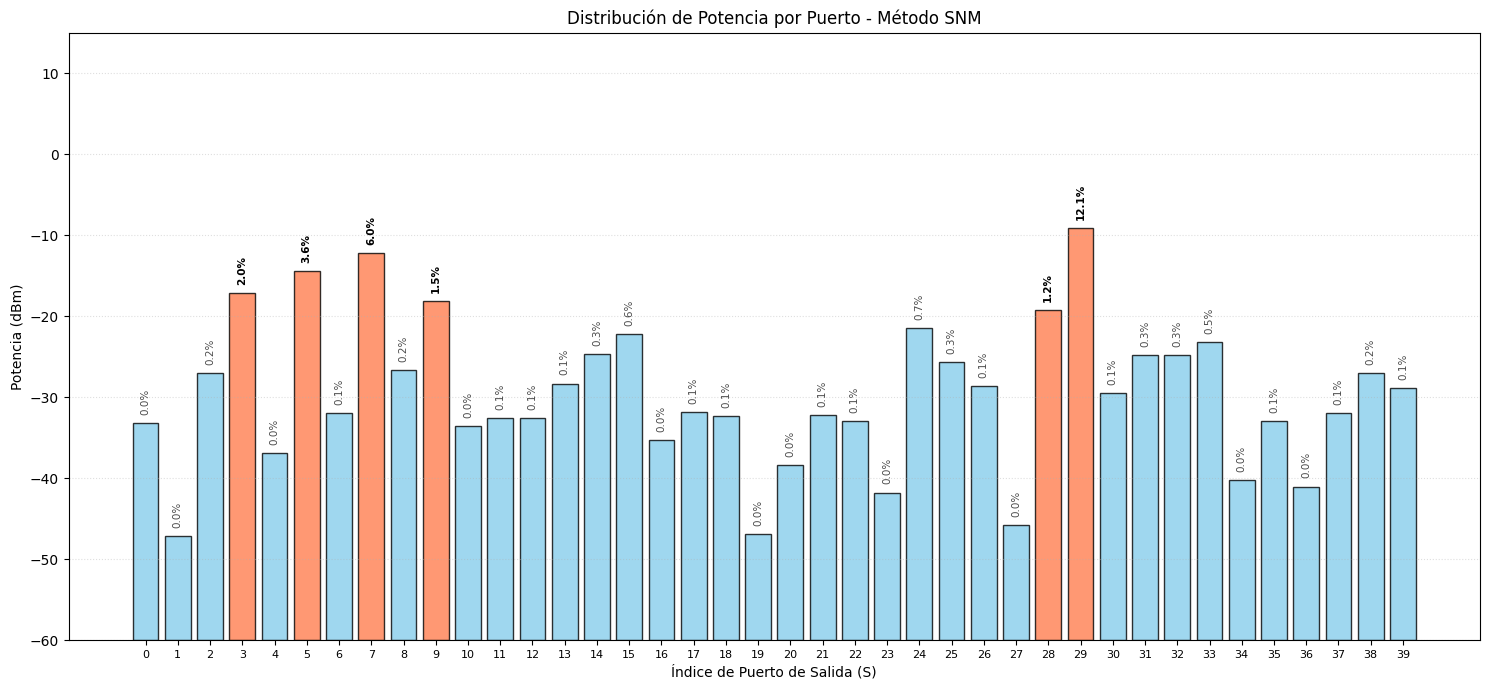

Balance Total: 31.45%


In [62]:
# 1. Creamos el chip (Hardware FIJO con seed=47)
tbus_columnas = [6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6]
malla = malla_SNM_completa(tbus_columnas, ideal=False, seed=47)

# 2. Generamos un fondo de fases que CAMBIA en cada ejecución
# Al usar seed=None, np.random.uniform dentro de programar_malla será libre
config_base = generar_configuracion_base_aleatoria(malla, seed=100)

# 3. Definimos tu RUTA FIJA al centro
# Esta lista sobreescribirá los valores de config_base para esas TBUs específicas
ruta_al_centro = [
    (21, "x"),
    (16, "x"),
    (10, "x"),
    (6, "x"),
    (0, "x"),
    (26, 0.5)
]

# Unimos ambas (convertimos a diccionario para pisar valores fácilmente)
config_dict = dict(config_base)
for idx, estado in ruta_al_centro:
    config_dict[idx] = estado

# Convertimos de vuelta a la lista de tuplas que espera programar_malla
config_final = list(config_dict.items())

# 4. Programamos y resolvemos
malla.programar_malla(config_final)
ids_40 = malla.obtener_ids_perimetrales_ordenados()
S_total = malla.resolver_matriz_total(ids_40)

# Potencia inyectada por puerto 0
potencias_salida = np.abs(S_total[:, 0])**2

# 5. Resultado visual
graficar_salida_dbm(potencias_salida, ids_40)
print(f"Balance Total: {np.sum(potencias_salida)*100:.2f}%")

Aplicando ruta manual para el puerto 0 hacia el centro...


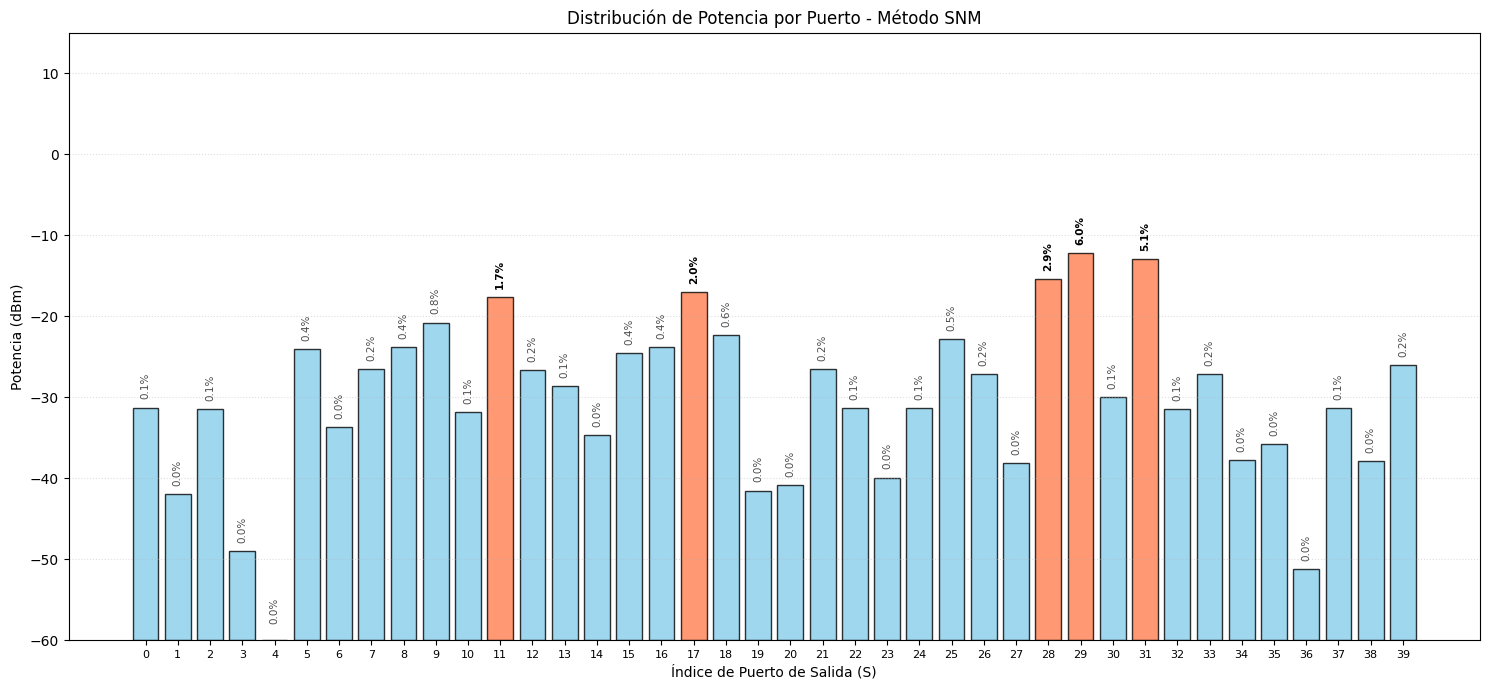

Prueba: 0 | Puerto de Entrada: 0 | Balance Total: 23.45%


In [69]:
# --- DICCIONARIO MAESTRO DE RUTAS AL CENTRO ---
# Clave: ID del Puerto Global | Valor: Lista de (ID_TBU, Estado)
rutas_maestras = {
    0: [  
        (0, "x"), (6, "x"), (10, "x"), (16, "x"), (21, "x"), (26, 0.5)
    ],
    
    1: [  
        (0, "="), (6, "x"), (10, "x"), (16, "x"), (21, "x"), (26, 0.5)
    ],
    
    2: [  
        (9, "x"), (10, "="), (16, "x"), (21, "x"), (26, 0.5)
    ],

    3: [  
        (15, "x"), (19, "="), (20, "x"), (21, "="), (26, 0.5)
    ],
    
    4: [  
        (15, "x"), (9, "="), (10, "="), (16, "x"), (21, "x"), (26, 0.5)
    ],
    
    5: [  
        (19, "x"), (20, "x"), (21, "="), (26, 0.5)
    ],
    26: [
        (43, "x"), (42, 0.5)
    ],






    
    28: [
        (66, "x"), (60, "x"), (55, "x"), (50, "x"), (45, 0.5)
    ],
   
}

# --- EJECUCIÓN DEL EXPERIMENTO ---

# 1. Configuración del Hardware (FIJO)
tbus_columnas = [6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6]
malla = malla_SNM_completa(tbus_columnas, ideal=False, seed=47)

# 2. Selección del puerto de entrada para este test
p_in = 0 
num_pruebas = 1
for n in range(num_pruebas):
    # 3. Generamos el fondo ALEATORIO que cambia en cada ejecución
    config_base = generar_configuracion_base_aleatoria(malla, seed=n*100)
    config_dict = dict(config_base)
    
    # 4. Aplicamos la RUTA FIJA si existe para ese puerto
    if p_in in rutas_maestras:
        print(f"Aplicando ruta manual para el puerto {p_in} hacia el centro...")
        for idx, estado in rutas_maestras[p_in]:
            config_dict[idx] = estado
    else:
        print(f"Aviso: No hay ruta manual para el puerto {p_in}, se usará todo aleatorio.")
    
    # 5. Programamos y Resolvemos
    malla.programar_malla(list(config_dict.items()))
    ids_40 = malla.obtener_ids_perimetrales_ordenados()
    S_total = malla.resolver_matriz_total(ids_40)
    
    # 6. Mapeo de puerto a columna de la matriz
    # Buscamos en qué posición de la lista 'ids_40' está nuestro puerto de entrada
    
    potencias_salida = np.abs(S_total[:, p_in])**2
    
    # 7. Resultado visual
    graficar_salida_dbm(potencias_salida, ids_40)
    print(f"Prueba: {n} | Puerto de Entrada: {p_in} | Balance Total: {np.sum(potencias_salida)*100:.2f}%")
    

Aviso: No hay ruta manual para el puerto 10, se usará todo aleatorio.


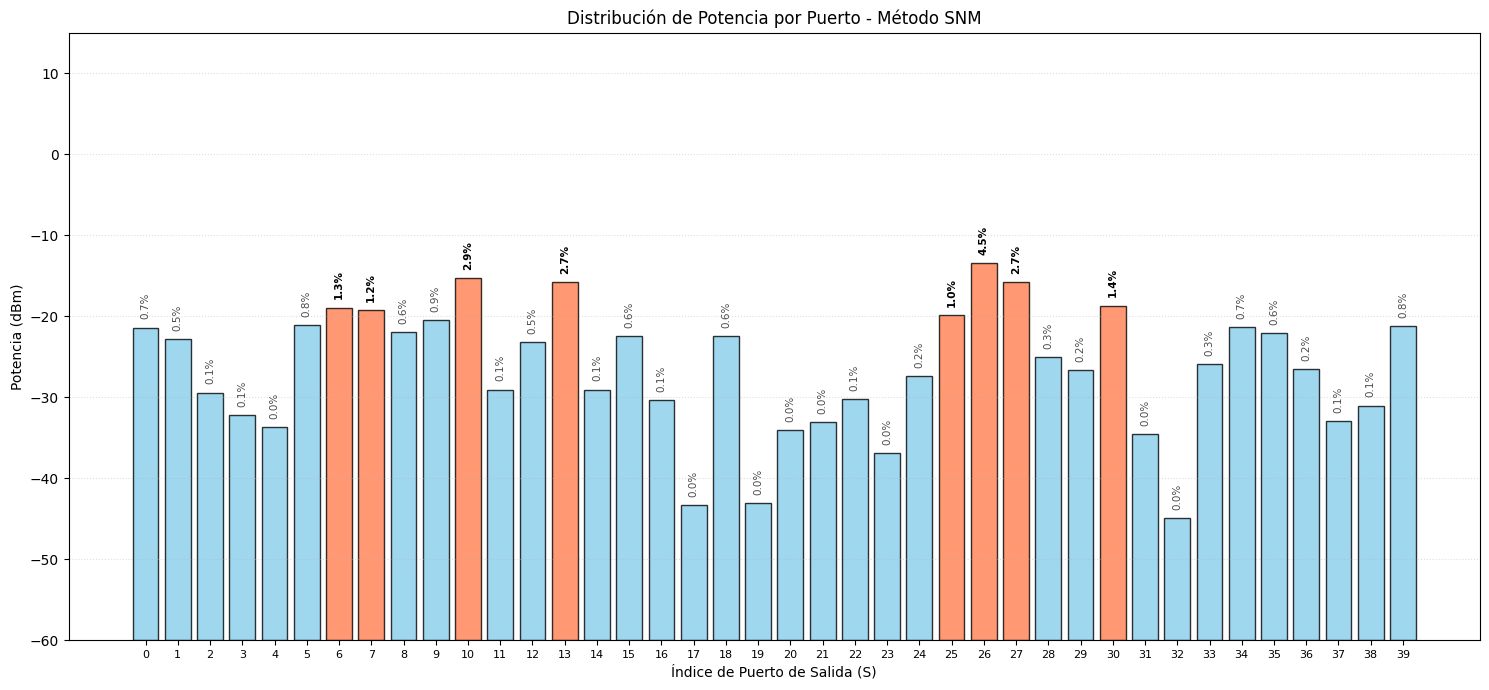

Puerto de Entrada: 10 | Balance Total: 27.08%


In [70]:

# 2. Selección del puerto de entrada para este test
p_in = 10 

# 3. Generamos el fondo ALEATORIO que cambia en cada ejecución
config_base = generar_configuracion_base_aleatoria(malla, seed=None)
config_dict = dict(config_base)

# 4. Aplicamos la RUTA FIJA si existe para ese puerto
if p_in in rutas_maestras:
    print(f"Aplicando ruta manual para el puerto {p_in} hacia el centro...")
    for idx, estado in rutas_maestras[p_in]:
        config_dict[idx] = estado
else:
    print(f"Aviso: No hay ruta manual para el puerto {p_in}, se usará todo aleatorio.")

# 5. Programamos y Resolvemos
malla.programar_malla(list(config_dict.items()))
ids_40 = malla.obtener_ids_perimetrales_ordenados()
S_total = malla.resolver_matriz_total(ids_40)

# 6. Mapeo de puerto a columna de la matriz
# Buscamos en qué posición de la lista 'ids_40' está nuestro puerto de entrada

potencias_salida = np.abs(S_total[:, p_in])**2

# 7. Resultado visual
graficar_salida_dbm(potencias_salida, ids_40)
print(f"Puerto de Entrada: {p_in} | Balance Total: {np.sum(potencias_salida)*100:.2f}%")


Iniciando comparativa de 100 retos (Puerto 0)...
>> Procesadas 25 / 100 configuraciones...
>> Procesadas 50 / 100 configuraciones...
>> Procesadas 75 / 100 configuraciones...
>> Procesadas 100 / 100 configuraciones...


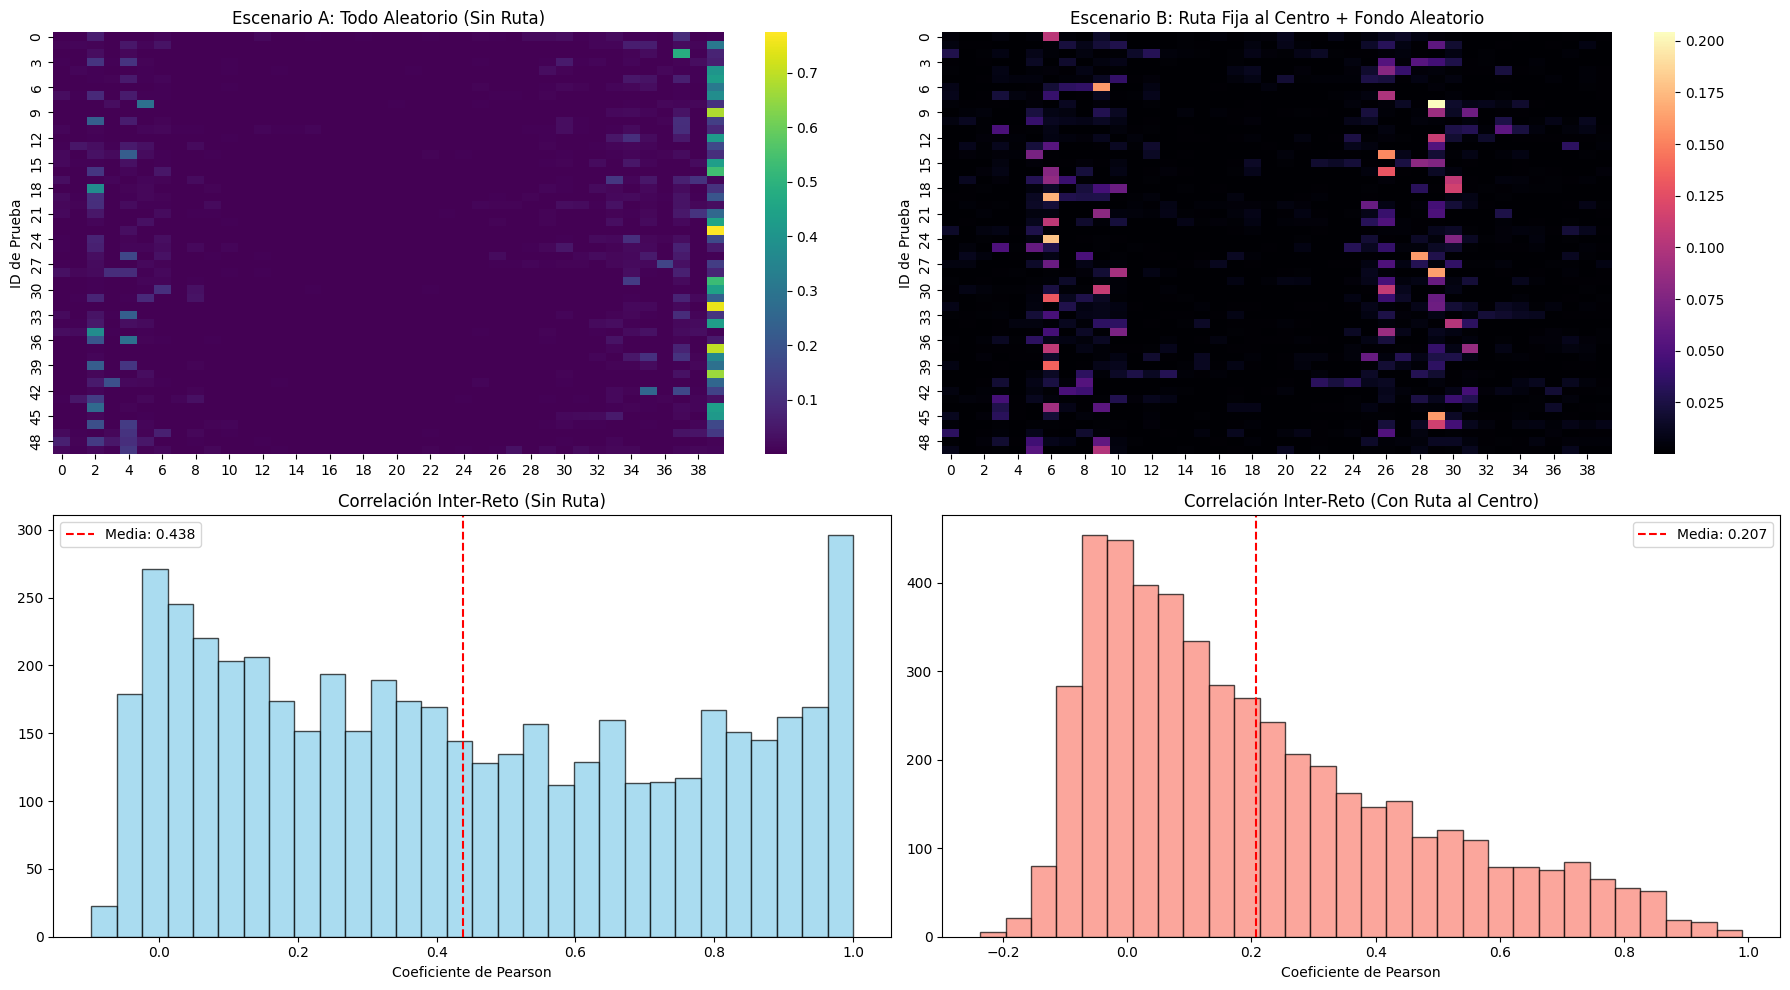


--- CONCLUSIONES TÉCNICAS ---
Correlación media SIN ruta: 0.4377
Correlación media CON ruta al centro: 0.2072


In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURACIÓN DEL EXPERIMENTO COMPARATIVO ---
num_pruebas = 100
p_in = 0  # Puerto de entrada fijo
seed_hardware = 47 # Chip fijo

# 1. Instancia del Chip
malla_puf = malla_SNM_completa(tbus_columnas, ideal=False, seed=seed_hardware)
ids_40 = malla_puf.obtener_ids_perimetrales_ordenados()


print(f"Iniciando comparativa de {num_pruebas} retos (Puerto {p_in})...")

resultados_con_centro = []
resultados_aleatorios = []

# 2. Bucle de Simulación
for i in range(num_pruebas):
    # Generamos un fondo aleatorio único para esta prueba
    config_base = generar_configuracion_base_aleatoria(malla_puf, seed=i)
    
    # --- ESCENARIO A: SIN CAMINO (TODO ALEATORIO) ---
    malla_puf.programar_malla(config_base)
    S_rand = malla_puf.resolver_matriz_total(ids_40)
    pot_rand = np.abs(S_rand[:, p_in])**2
    resultados_aleatorios.append(pot_rand)
    
    # --- ESCENARIO B: CON CAMINO AL CENTRO ---
    config_dict = dict(config_base)
    if p_in in rutas_maestras:
        for tbu_id, estado in rutas_maestras[p_in]:
            config_dict[tbu_id] = estado
            
    malla_puf.programar_malla(list(config_dict.items()))
    S_centro = malla_puf.resolver_matriz_total(ids_40)
    pot_centro = np.abs(S_centro[:, p_in])**2
    resultados_con_centro.append(pot_centro)
    
    if (i + 1) % 25 == 0:
        print(f">> Procesadas {i + 1} / {num_pruebas} configuraciones...")

# Convertimos a matrices
matriz_rand = np.array(resultados_aleatorios)
matriz_centro = np.array(resultados_con_centro)

# 3. Cálculo de Correlaciones
corr_rand = pd.DataFrame(matriz_rand.T).corr().values[np.triu_indices(num_pruebas, k=1)]
corr_centro = pd.DataFrame(matriz_centro.T).corr().values[np.triu_indices(num_pruebas, k=1)]

# 4. VISUALIZACIÓN COMPARATIVA
plt.figure(figsize=(18, 10))

# --- MAPAS DE CALOR (Firma Óptica) ---
plt.subplot(2, 2, 1)
sns.heatmap(matriz_rand[:50, :], cmap='viridis')
plt.title("Escenario A: Todo Aleatorio (Sin Ruta)")
plt.ylabel("ID de Prueba")

plt.subplot(2, 2, 2)
sns.heatmap(matriz_centro[:50, :], cmap='magma')
plt.title("Escenario B: Ruta Fija al Centro + Fondo Aleatorio")
plt.ylabel("ID de Prueba")

# --- HISTOGRAMAS DE UNICIDAD (Correlación) ---
plt.subplot(2, 2, 3)
plt.hist(corr_rand, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(corr_rand), color='red', linestyle='--', label=f'Media: {np.mean(corr_rand):.3f}')
plt.title("Correlación Inter-Reto (Sin Ruta)")
plt.xlabel("Coeficiente de Pearson")
plt.legend()

plt.subplot(2, 2, 4)
plt.hist(corr_centro, bins=30, color='salmon', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(corr_centro), color='red', linestyle='--', label=f'Media: {np.mean(corr_centro):.3f}')
plt.title("Correlación Inter-Reto (Con Ruta al Centro)")
plt.xlabel("Coeficiente de Pearson")
plt.legend()

plt.tight_layout()
plt.show()

print(f"\n--- CONCLUSIONES TÉCNICAS ---")
print(f"Correlación media SIN ruta: {np.mean(corr_rand):.4f}")
print(f"Correlación media CON ruta al centro: {np.mean(corr_centro):.4f}")

Iniciando comparativa de 100 retos (Puerto 26)...
>> Procesadas 25 / 100 configuraciones...
>> Procesadas 50 / 100 configuraciones...
>> Procesadas 75 / 100 configuraciones...
>> Procesadas 100 / 100 configuraciones...


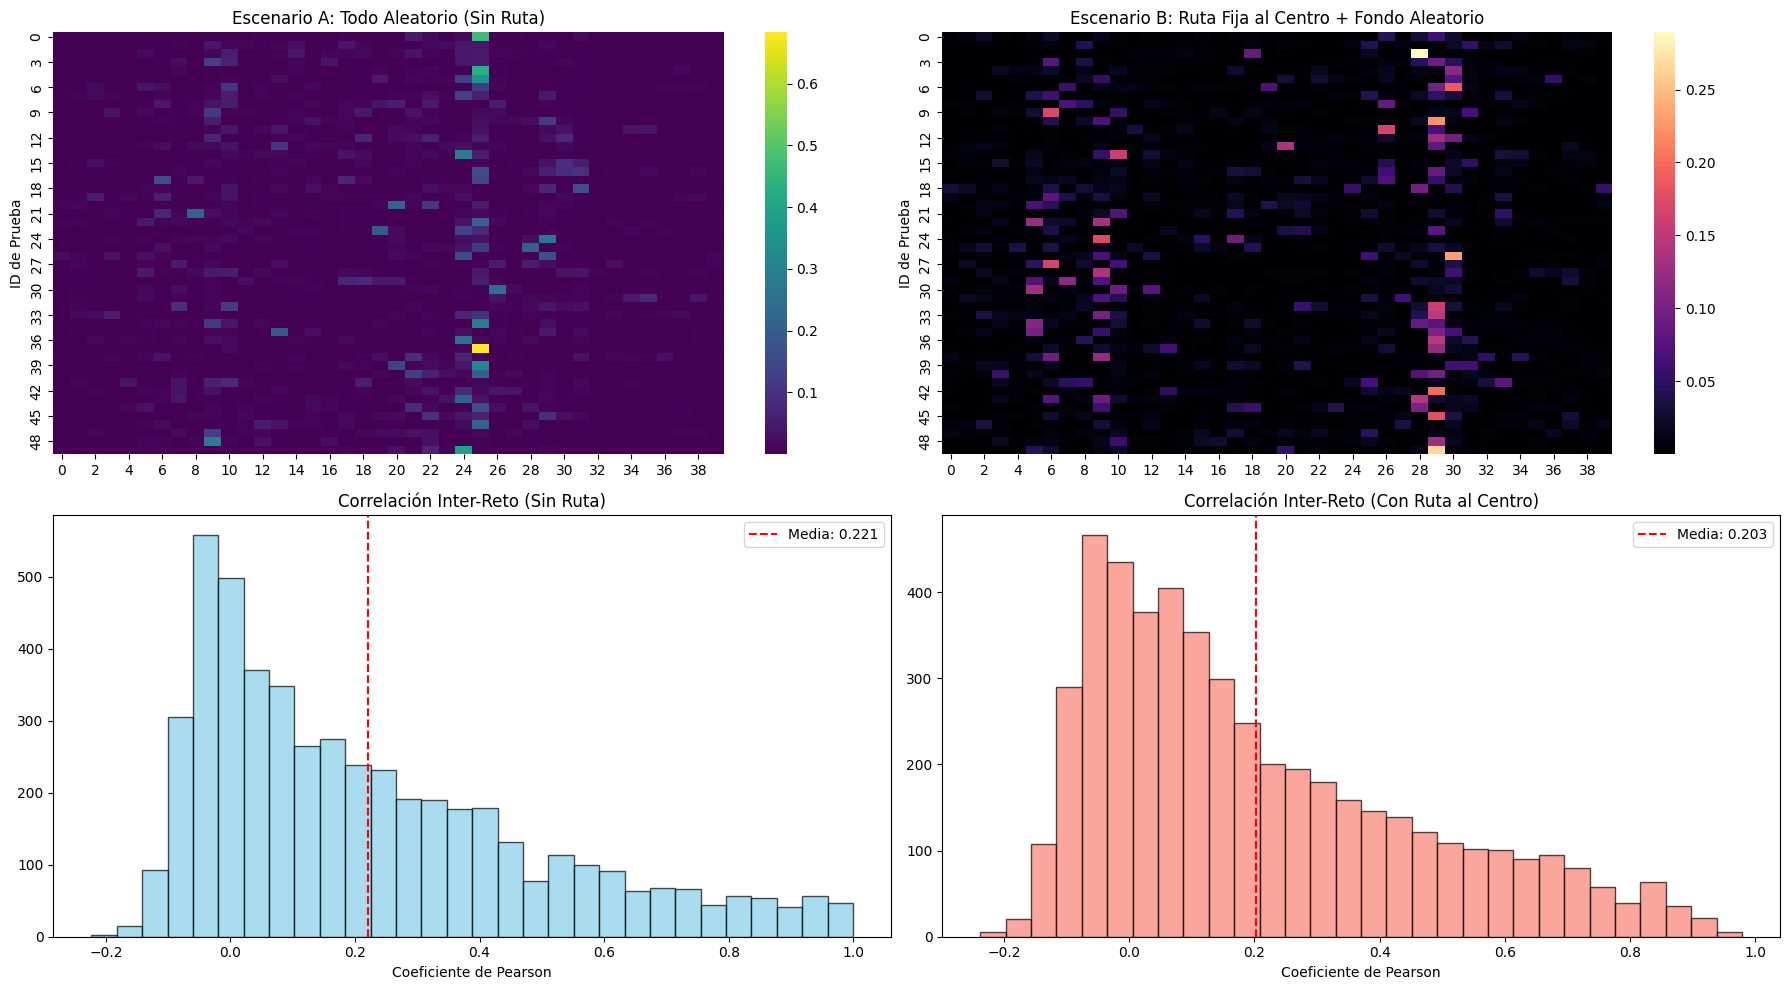


--- CONCLUSIONES TÉCNICAS ---
Correlación media SIN ruta: 0.2206
Correlación media CON ruta al centro: 0.2030


In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURACIÓN DEL EXPERIMENTO COMPARATIVO ---
num_pruebas = 100
p_in = 26  # Puerto de entrada fijo
seed_hardware = 47 # Chip fijo

# 1. Instancia del Chip
malla_puf = malla_SNM_completa(tbus_columnas, ideal=False, seed=seed_hardware)
ids_40 = malla_puf.obtener_ids_perimetrales_ordenados()


print(f"Iniciando comparativa de {num_pruebas} retos (Puerto {p_in})...")

resultados_con_centro = []
resultados_aleatorios = []

# 2. Bucle de Simulación
for i in range(num_pruebas):
    # Generamos un fondo aleatorio único para esta prueba
    config_base = generar_configuracion_base_aleatoria(malla_puf, seed=i)
    
    # --- ESCENARIO A: SIN CAMINO (TODO ALEATORIO) ---
    malla_puf.programar_malla(config_base)
    S_rand = malla_puf.resolver_matriz_total(ids_40)
    pot_rand = np.abs(S_rand[:, p_in])**2
    resultados_aleatorios.append(pot_rand)
    
    # --- ESCENARIO B: CON CAMINO AL CENTRO ---
    config_dict = dict(config_base)
    if p_in in rutas_maestras:
        for tbu_id, estado in rutas_maestras[p_in]:
            config_dict[tbu_id] = estado
            
    malla_puf.programar_malla(list(config_dict.items()))
    S_centro = malla_puf.resolver_matriz_total(ids_40)
    pot_centro = np.abs(S_centro[:, p_in])**2
    resultados_con_centro.append(pot_centro)
    
    if (i + 1) % 25 == 0:
        print(f">> Procesadas {i + 1} / {num_pruebas} configuraciones...")

# Convertimos a matrices
matriz_rand = np.array(resultados_aleatorios)
matriz_centro = np.array(resultados_con_centro)

# 3. Cálculo de Correlaciones
corr_rand = pd.DataFrame(matriz_rand.T).corr().values[np.triu_indices(num_pruebas, k=1)]
corr_centro = pd.DataFrame(matriz_centro.T).corr().values[np.triu_indices(num_pruebas, k=1)]

# 4. VISUALIZACIÓN COMPARATIVA
plt.figure(figsize=(18, 10))

# --- MAPAS DE CALOR (Firma Óptica) ---
plt.subplot(2, 2, 1)
sns.heatmap(matriz_rand[:50, :], cmap='viridis')
plt.title("Escenario A: Todo Aleatorio (Sin Ruta)")
plt.ylabel("ID de Prueba")

plt.subplot(2, 2, 2)
sns.heatmap(matriz_centro[:50, :], cmap='magma')
plt.title("Escenario B: Ruta Fija al Centro + Fondo Aleatorio")
plt.ylabel("ID de Prueba")

# --- HISTOGRAMAS DE UNICIDAD (Correlación) ---
plt.subplot(2, 2, 3)
plt.hist(corr_rand, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(corr_rand), color='red', linestyle='--', label=f'Media: {np.mean(corr_rand):.3f}')
plt.title("Correlación Inter-Reto (Sin Ruta)")
plt.xlabel("Coeficiente de Pearson")
plt.legend()

plt.subplot(2, 2, 4)
plt.hist(corr_centro, bins=30, color='salmon', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(corr_centro), color='red', linestyle='--', label=f'Media: {np.mean(corr_centro):.3f}')
plt.title("Correlación Inter-Reto (Con Ruta al Centro)")
plt.xlabel("Coeficiente de Pearson")
plt.legend()

plt.tight_layout()
plt.show()

print(f"\n--- CONCLUSIONES TÉCNICAS ---")
print(f"Correlación media SIN ruta: {np.mean(corr_rand):.4f}")
print(f"Correlación media CON ruta al centro: {np.mean(corr_centro):.4f}")